In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

- k-meansクラスタリング

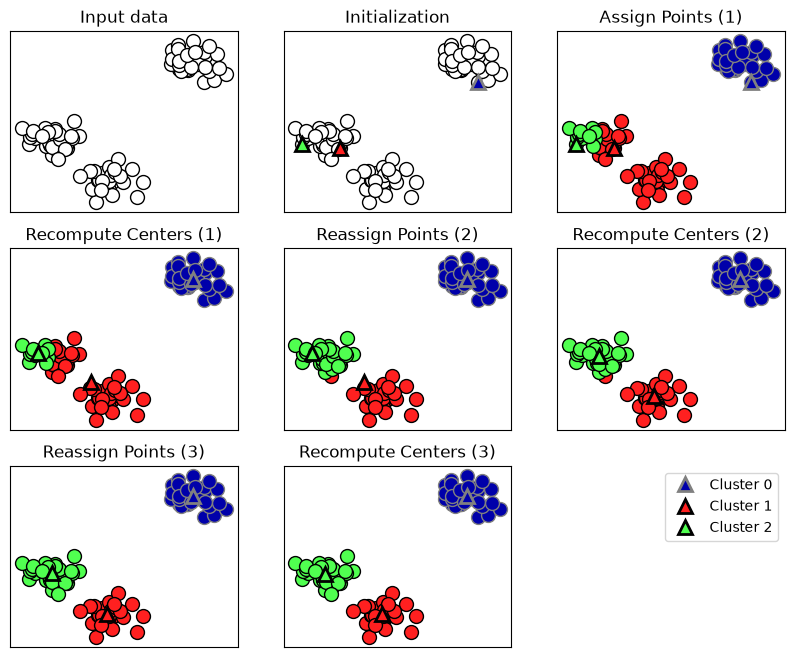

In [2]:
mglearn.plots.plot_kmeans_algorithm()

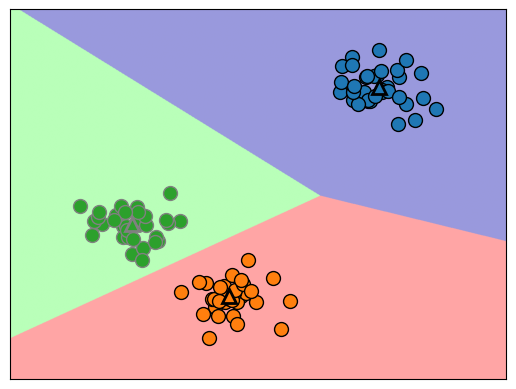

In [3]:
#クラスタセンタの境界を示す
mglearn.plots.plot_kmeans_boundaries()
plt.show()

In [3]:
#k-meansのクラスタリングを行う
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

x,y = make_blobs(random_state=1)

kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
print("Cluster memberships:\n{}".format(kmeans.labels_))

Cluster memberships:
[1 2 2 2 0 0 0 2 1 1 2 2 0 1 0 0 0 1 2 2 0 2 0 1 2 0 0 1 1 0 1 1 0 1 2 0 2
 2 2 0 0 2 1 2 2 0 1 1 1 1 2 0 0 0 1 0 2 2 1 1 2 0 0 2 2 0 1 0 1 2 2 2 0 1
 1 2 0 0 1 2 1 2 2 0 1 1 1 1 2 1 0 1 1 2 2 0 0 1 0 1]


In [5]:
#訓練セットに対してpredictを行うと、kmeans.labels_と同じ結果が得られる
print(kmeans.predict(x))

[0 2 2 2 1 1 1 2 0 0 2 2 1 0 1 1 1 0 2 2 1 2 1 0 2 1 1 0 0 1 0 0 1 0 2 1 2
 2 2 1 1 2 0 2 2 1 0 0 0 0 2 1 1 1 0 1 2 2 0 0 2 1 1 2 2 1 0 1 0 2 2 2 1 0
 0 2 1 1 0 2 0 2 2 1 0 0 0 0 2 0 1 0 0 2 2 1 1 0 1 0]


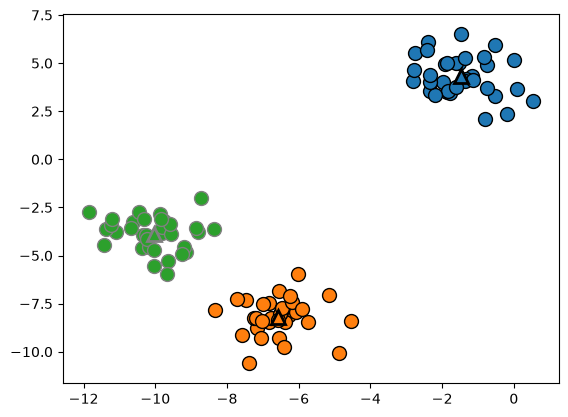

In [6]:
mglearn.discrete_scatter(x[:, 0], x[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
    markers='^', markeredgewidth=2)
plt.show()

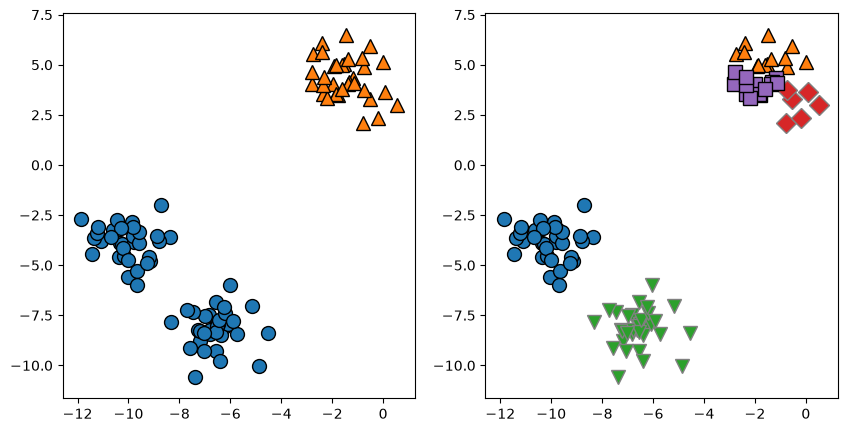

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

kmeans = KMeans(n_clusters=2)
kmeans.fit(x)
assignments = kmeans.labels_
mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments, ax=axes[0])

kmeans = KMeans(n_clusters=5)
kmeans.fit(x)
assignments = kmeans.labels_
mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments, ax=axes[1])

plt.show()

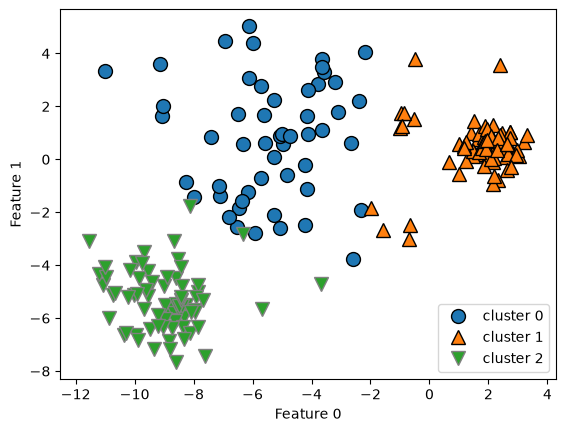

In [8]:
#k-meansでは比較的単純な形しか表現できない
#K-meansは「丸っぽく、同程度の大きさ・密度のクラスタ」には強いが、
# クラスタの大きさや広がりが大きく異なるデータでは、直感的なグループ分けとズレることがある。

x_varied,y_varied = make_blobs(n_samples=200, 
                               cluster_std=[1.0,2.5,0.5], 
                               random_state=170
                               )

y_pred = KMeans(n_clusters=3, random_state=0).fit_predict(x_varied)
mglearn.discrete_scatter(x_varied[:, 0], x_varied[:, 1], y_pred)
plt.legend(["cluster 0", "cluster 1", "cluster 2"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

In [2]:
#k-meansは最も近いクラスタセンタへの距離しか考慮しないので、このようなデータを取り扱うことはできない
#k-meansは丸くないクラスタを識別できない

#ランダムにクラスタデータを生成
x,y = make_blobs(n_samples=600,
                 random_state=170
)
rng = np.random.RandomState(74)

#回転・拡大縮小・せん断などが混ざった線形変換をする
taransformation = rng.normal(size=(2,2))
x = np.dot(x, taransformation)

#データポイントを３つにクラスタリング
kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
y_pred = kmeans.predict(x)

#クラスタ割り当てとクラスタセンタをプロット
plt.scatter(x[:, 0], x[:, 1], c=y_pred, s=60, cmap=mglearn.cm3)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='^', c=[0, 1, 2], s=100, linewidth=2, cmap=mglearn.cm3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()



NameError: name 'make_blobs' is not defined

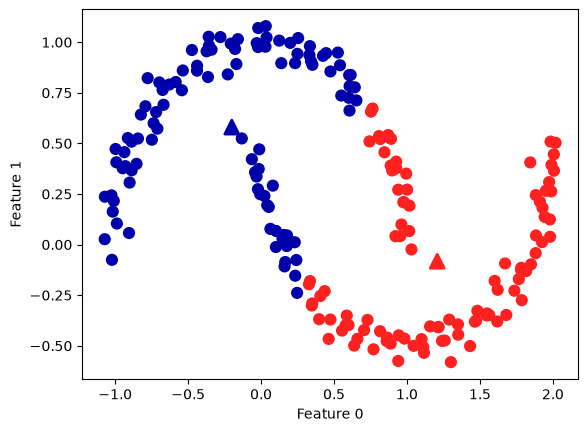

In [10]:
#k-means法はクラスタが複雑な形の場合もうまく機能しない
from sklearn.datasets import make_moons
x,y = make_moons(n_samples=200, noise=0.05, random_state=0)

kmeans = KMeans(n_clusters=2)
kmeans.fit(x)
y_pred = kmeans.predict(x)


plt.scatter(x[:, 0], x[:, 1], c=y_pred, s=60, cmap=mglearn.cm2)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='^', c=[0, 1], s=100, linewidth=2, cmap=mglearn.cm2)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

In [11]:
#PCA,NMFとk-means法を抽出された成分で比較してみよう

from sklearn.decomposition import NMF
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)

mask = np.zeros(people.target.shape, dtype=np.bool)
for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = 1
    
X_people = people.data[mask]
y_people = people.target[mask]

X_people = X_people / 255.


X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=0)
nmf = NMF(n_components=100, random_state=0)
nmf.fit(X_train)
pca = PCA(n_components=100, random_state=0)
pca.fit(X_train)
kmeans = KMeans(n_clusters=100, random_state=0)
kmeans.fit(X_train)

X_reconstructed_pca = pca.inverse_transform(pca.transform(X_test))
X_reconstructed_kmeans = kmeans.cluster_centers_[kmeans.predict(X_test)]
X_reconstructed_nmf = np.dot(nmf.transform(X_test), nmf.components_)

c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


KeyboardInterrupt: 

In [12]:
#PCA,NMFとk-means法を抽出された成分で比較してみる
#Meansによるベクトル量子化は、各データを「最も近いクラスタ中心1個」で表現する

from sklearn.datasets import fetch_lfw_people
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
image_shape = people.images[0].shape

fig, axes = plt.subplots(3, 5, figsize=(8, 8),
                         subplot_kw={'xticks': (), 'yticks': ()})
fig.suptitle("Extracted Components")
for ax, comp_kmeans, comp_pca, comp_nmf in zip(
        axes.T, kmeans.cluster_centers_, pca.components_, nmf.components_):
    ax[0].imshow(comp_kmeans.reshape(image_shape), cmap='gray')
    ax[1].imshow(comp_pca.reshape(image_shape) , cmap='gray')
    ax[2].imshow(comp_nmf.reshape(image_shape) , cmap='gray')

axes[0, 0].set_ylabel("kmeans")
axes[1, 0].set_ylabel("pca")
axes[2, 0].set_ylabel("nmf")

fig, axes = plt.subplots(4, 5, subplot_kw={'xticks': (), 'yticks': ()},
                         figsize=(8, 8))
fig.suptitle("Reconstructions")
for ax, orig, rec_kmeans, rec_pca, rec_nmf in zip(
        axes.T, X_test, X_reconstructed_kmeans, X_reconstructed_pca,
        X_reconstructed_nmf):

    ax[0].imshow(orig.reshape(image_shape), cmap='gray')
    ax[1].imshow(rec_kmeans.reshape(image_shape), cmap='gray')
    ax[2].imshow(rec_pca.reshape(image_shape), cmap='gray')
    ax[3].imshow(rec_nmf.reshape(image_shape), cmap='gray')

axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("kmeans")
axes[2, 0].set_ylabel("pca")
axes[3, 0].set_ylabel("nmf")
plt.show()

AttributeError: 'KMeans' object has no attribute 'cluster_centers_'

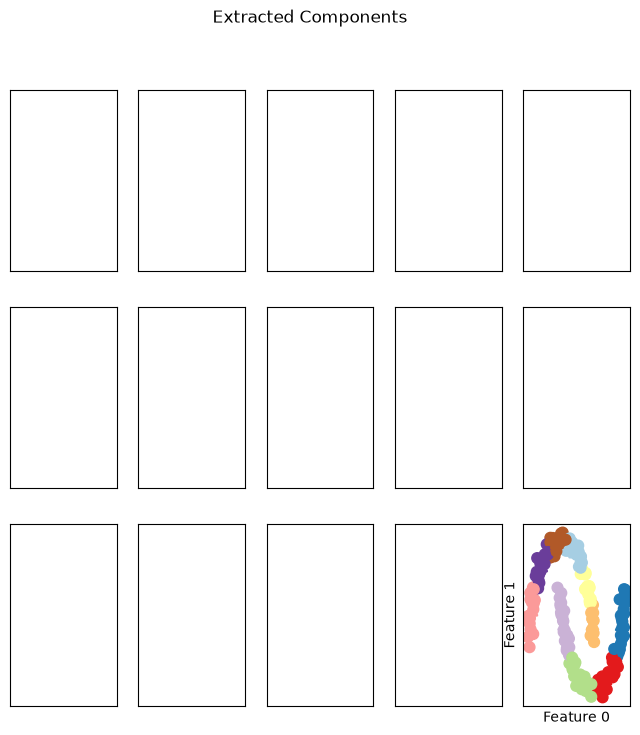

Cluster memberships:
[8 4 6 3 1 1 5 2 8 4 9 2 1 4 7 5 0 2 0 7 1 2 0 4 9 6 1 1 6 0 8 9 2 6 8 1 2
 5 3 6 2 7 8 6 4 9 5 7 6 2 7 2 1 3 4 8 0 4 0 9 2 3 1 8 4 3 9 4 9 3 2 3 2 6
 2 3 6 8 0 2 1 9 2 1 6 9 5 9 2 1 0 5 1 7 1 1 4 2 3 6 4 1 9 5 3 6 3 7 4 0 7
 9 9 3 8 4 8 1 2 8 8 7 6 9 6 7 5 6 4 1 5 7 3 6 4 4 4 3 1 8 6 6 0 9 7 5 6 4
 0 6 2 4 8 0 2 9 4 2 0 0 6 4 0 4 2 1 0 2 4 2 0 3 3 7 6 2 1 7 7 0 4 3 1 4 1
 0 9 2 3 7 3 0 8 5 6 7 1 6 9 4]


In [13]:
#k-means法で多数のクラスタセンタを用いると、もっと強力な表現を見つけることができる
#元の二次元のデータを、クラスタセンタの数だけの次元に変換することで、より複雑な形状のデータを表現できるようになる。

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(X)
y_pred = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=60, cmap='Paired')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=60,
            marker='^', c=range(kmeans.n_clusters), linewidth=2, cmap='Paired')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()
print("Cluster memberships:\n{}".format(y_pred))

In [14]:
#さらに、個々のクラスタセンタを特徴量として用いることで、より複雑な形状のデータを表現できるようになる。

#transform(X) は、各データについてクラスタ中心それぞれまでの距離を計算する
#これにより、元の二次元のデータを、クラスタセンタの数だけの次元に変換することができる
distance_features = kmeans.transform(X)
print("Original shape: {}".format(X.shape))
print("Transformed shape: {}".format(distance_features.shape))
print("Distance features:\n{}".format(distance_features))

Original shape: (200, 2)
Transformed shape: (200, 10)
Distance features:
[[0.53664613 1.15017588 0.93237626 ... 1.48034956 0.002907   1.07736639]
 [1.74138152 0.60592307 1.00666225 ... 2.52921971 1.20779969 2.23716489]
 [0.75710543 1.93145038 0.91586549 ... 0.78321505 0.87573753 0.71838465]
 ...
 [0.9274342  1.73811046 0.57899268 ... 1.11471941 0.83358544 1.04125672]
 [0.3227627  1.97647071 1.47861069 ... 0.81425026 0.84551232 0.28446737]
 [1.63322944 0.47226506 1.02289983 ... 2.46626118 1.09767675 2.14812753]]


- 疑集型クラスタリング

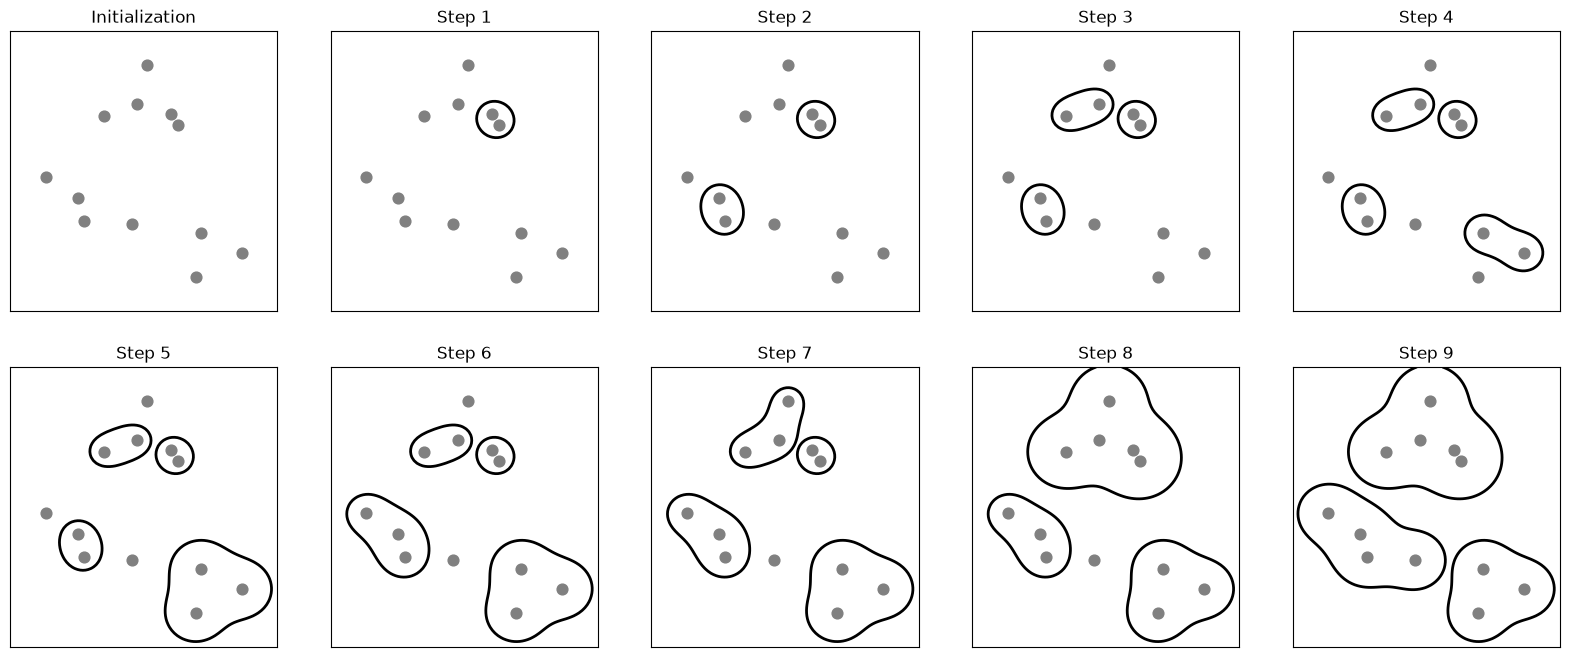

In [15]:
#wardで、疑似的なクラスタを結合していくことで、より複雑な形状のデータを表現できるようになる。
#クラスタ数が３つになるところで終了
mglearn.plots.plot_agglomerative_algorithm()
plt.show()

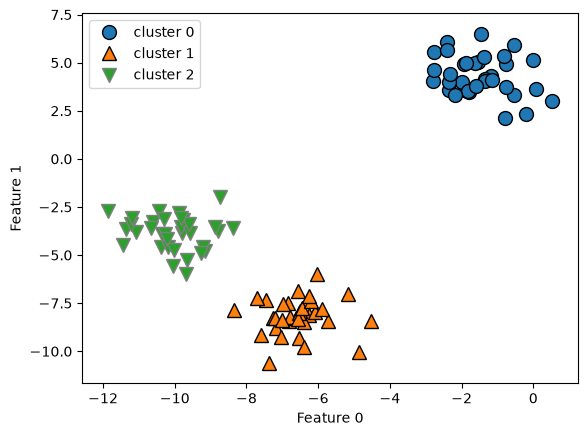

In [ ]:
#疑集合クラスタリングは新しいデータに対して予測することができない
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

x,y = make_blobs(random_state=1)
agg = AgglomerativeClustering(n_clusters=3)
assignments = agg.fit_predict(x)

mglearn.discrete_scatter(x[:, 0], x[:, 1], assignments)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["cluster 0", "cluster 1", "cluster 2"], loc="best")
plt.show()

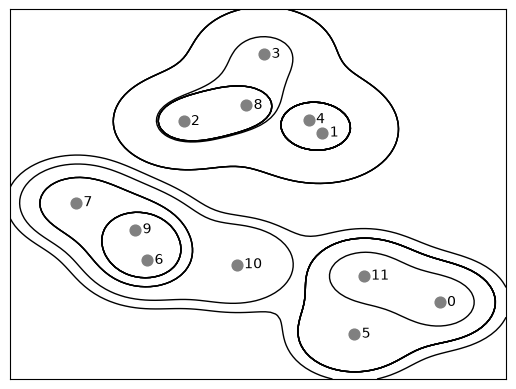

In [16]:
#階層型クラスタリング
#ステップごとにクラスタの数が減っていく過程で得られる、全てのクラスタを重ねて表示する

mglearn.plots.plot_agglomerative()
plt.show()

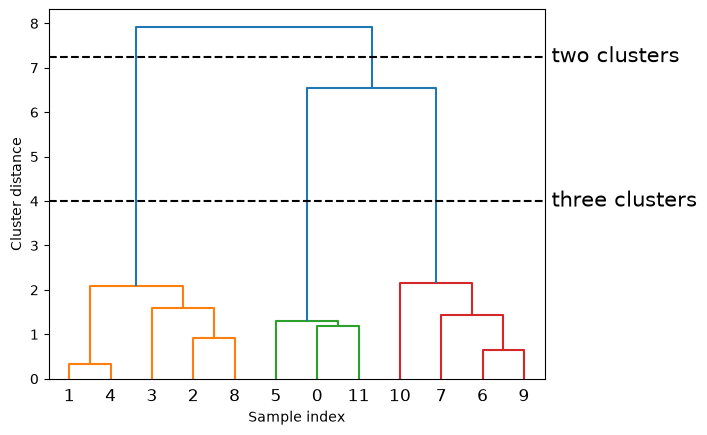

In [ ]:
#階層型クラスタをデンドログラムによって可視化
#木構造としてプロットする

from scipy.cluster.hierarchy import dendrogram, ward
X, y = make_blobs(random_state=0, n_samples=12)

#scipyのward関数は、凝集型クラスタリングを行った際のブリッジ距離の配列
linkage_array = ward(X)
#クラスタ間距離をデンドログラムとしてプロット
dendrogram(linkage_array)

ax = plt.gca()
bounds = ax.get_xbound()
ax.plot(bounds, [7.25, 7.25], '--', c='k')
ax.plot(bounds, [4, 4], '--', c='k')

ax.text(bounds[1], 7.25, ' two clusters', va='center', fontdict={'size': 15})
ax.text(bounds[1], 4, ' three clusters', va='center', fontdict={'size': 15})
plt.xlabel("Sample index")
plt.ylabel("Cluster distance")
plt.show()

- DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
x,y = make_blobs(random_state=0, n_samples=12)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(x)

#すべてのデータポイントがノイズを表すー１になっている
#これはmin_samplesのデフォルト設定が小さいトイデータセットに適していないため
print("Cluster memberships:\n{}".format(clusters))

Cluster memberships:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


min_samples: 2 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 2 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 2 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 2 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 3 eps: 1.000000  cluster: [-1  0  0 -1  0 -1  1  1  0  1 -1 -1]
min_samples: 3 eps: 1.500000  cluster: [0 1 1 1 1 0 2 2 1 2 2 0]
min_samples: 3 eps: 2.000000  cluster: [0 1 1 1 1 0 0 0 1 0 0 0]
min_samples: 3 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]
min_samples: 5 eps: 1.000000  cluster: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
min_samples: 5 eps: 1.500000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 2.000000  cluster: [-1  0  0  0  0 -1 -1 -1  0 -1 -1 -1]
min_samples: 5 eps: 3.000000  cluster: [0 0 0 0 0 0 0 0 0 0 0 0]


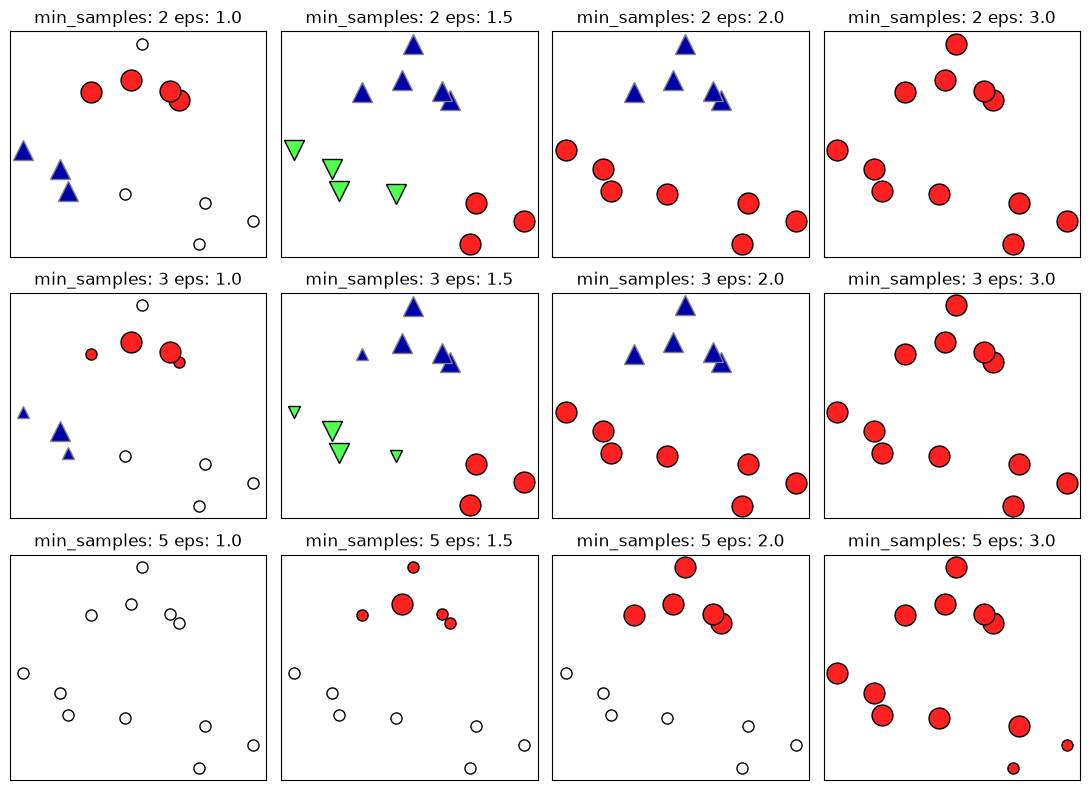

In [5]:
#min_samplesとepsを様々な値に設定したものを示す
mglearn.plots.plot_dbscan()

Text(0, 0.5, 'Feature 1')

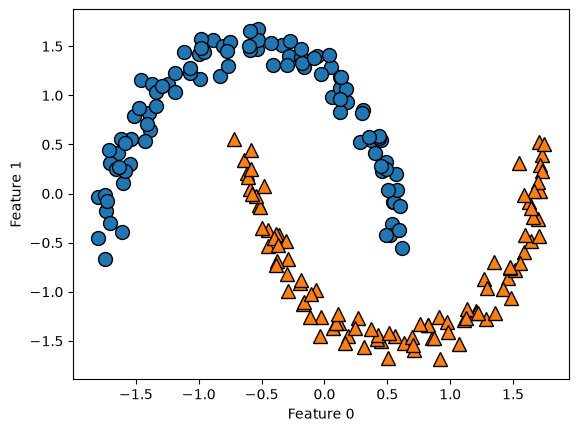

In [ ]:
#DBSCANをtwo_moonsデータセットに適用してみる
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

x,y = make_moons(n_samples=200, noise=0.05, random_state=0)

#データを平均１、標準偏差０に正規化する
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(x_scaled)

#クラスタリングの結果をプロット
# DBSCANは「データの密度」を利用するため、two_moonsのような曲がった形のクラスタも分離できる
mglearn.discrete_scatter(x_scaled[:, 0], x_scaled[:, 1], clusters)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

